# BetFlow — Analisi delle transazioni di SatoshiDice

Il presente elaborato analizza l'attività di SatoshiDice attraverso i dati pubblicamente disponibili sulla blockchain Bitcoin. L'obiettivo principale consiste nel ricostruire il flusso delle transazioni di scommessa e dei relativi payout, esaminare il comportamento degli utenti e individuare eventuali catene di puntate tra loro collegate.

## Indice

1. Fase 1 — Preparazione e controllo dei dati
2. Fase 2 — Modellazione dei dati e ricostruzione degli UTXO

## Fase 1 — Preparazione e controllo dei dati

La prima fase è dedicata alla predisposizione dell'ambiente di lavoro e alla valutazione preliminare della qualità dei dati. In particolare, vengono documentate la struttura e la provenienza dei dataset e vengono esaminati il numero di osservazioni, le colonne disponibili, i tipi di dato, la presenza di duplicati o valori mancanti e l'intervallo temporale coperto. Viene inoltre verificata l'unità di misura degli importi monetari.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import platform
import sys

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
SEED = 42

print(f"Python: {sys.version.split()[0]}")
print(f"Piattaforma: {platform.platform()}")
print(f"pandas: {pd.__version__} | numpy: {np.__version__}")

Python: 3.10.15
Piattaforma: macOS-26.5.2-arm64-arm-64bit
pandas: 2.3.3 | numpy: 2.2.6


### Configurazione dell'ambiente di lavoro

La cella seguente definisce le costanti e le strutture di supporto necessarie per garantire una gestione coerente e riproducibile dei dati. Nello specifico:

- individua la directory principale del progetto;
- consente di selezionare una modalità di caricamento campionaria oppure completa, in funzione delle risorse computazionali disponibili;
- stabilisce il fattore di conversione tra Bitcoin e satoshi (`1 BTC = 100.000.000 satoshi`);
- raccoglie nel dizionario `DATASETS` i percorsi, i separatori e gli schemi necessari alla lettura dei file.

In [2]:
PROJECT_DIR = Path.cwd().resolve()
RAW_DATA_DIR = PROJECT_DIR

SATOSHI_PER_BTC = 100_000_000

# False: usa un campione; True: carica tutte le righe dei dataset.
FULL_VALIDATION = True
SAMPLE_SIZE = 100_000
SAMPLE_ROWS = None if FULL_VALIDATION else SAMPLE_SIZE

DATASETS = {
    "transactions": {
        "path": RAW_DATA_DIR / "transactions.csv",
        "sep": ",",
        "columns": ["timestamp", "blockId", "txId", "isCoinbase", "fee"],
    },
    "inputs": {
        "path": RAW_DATA_DIR / "inputs.csv",
        "sep": ",",
        "columns": ["txId", "prevTxId", "prevTxPos"],
    },
    "outputs": {
        "path": RAW_DATA_DIR / "outputs.csv",
        "sep": ",",
        "columns": ["txId", "position", "addressId", "amount_satoshi", "scriptType"],
    },
    "address_mapping": {
        "path": RAW_DATA_DIR / "mapAddr2Ids8708820.csv",
        "sep": ",",
        "columns": ["address", "addressId"],
    },
}
SATOSHI_DICE_PATH = RAW_DATA_DIR / "satoshiDiceInfos.tsv"

print(f"Cartella progetto: {PROJECT_DIR}")
print(
    "Modalità di caricamento: dataset completo"
    if FULL_VALIDATION
    else f"Modalità di caricamento: campione di {SAMPLE_ROWS:,} righe per file"
)

Cartella progetto: /Users/antoniofatticcioni/Desktop/Università/Lab_Web_Scraping/Progetto_Lab_web_scraping
Modalità di caricamento: dataset completo


### Caricamento preliminare dei dataset

La cella seguente acquisisce i file che compongono la base dati e memorizza i corrispondenti DataFrame nel dizionario `frames`. Il file relativo a SatoshiDice viene trattato separatamente, poiché presenta una riga iniziale contenente la fonte e una struttura dei separatori differente rispetto agli altri file. Per ciascun dataset vengono infine riportati il numero di righe, il numero di colonne e un'anteprima delle osservazioni, così da verificare la correttezza della procedura di lettura.

In [3]:
def read_headerless_dataset(config, nrows=SAMPLE_ROWS):
    return pd.read_csv(
        config["path"],
        sep=config["sep"],
        names=config["columns"],
        header=None,
        nrows=nrows,
        low_memory=False,
    )

frames = {name: read_headerless_dataset(cfg) for name, cfg in DATASETS.items()} #.items produce coppie chiave valore

# Il file SatoshiDice contiene una riga di provenienza prima dell'intestazione.
satoshi_dice = pd.read_csv(
    SATOSHI_DICE_PATH,
    sep=r"\t|\s{2,}",  # tab nell'header, spazi multipli nelle righe
    engine="python",
    skiprows=1,  # salta la riga iniziale contenente l'URL della fonte
)
satoshi_dice.columns = satoshi_dice.columns.str.strip()
satoshi_dice = satoshi_dice.apply(
    lambda column: column.str.strip() if column.dtype == "object" else column #rimuove spazi bianchi se colonna contiene testo
)
frames["satoshi_dice"] = satoshi_dice

for name, frame in frames.items():
    print(f"{name}: {frame.shape[0]:,} righe × {frame.shape[1]} colonne")
    display(frame.head(6))

outputs = frames["outputs"].copy()
transactions = frames["transactions"].copy()
mapping = frames["address_mapping"].copy()
inputs = frames["inputs"].copy()
satoshi_dice = frames["satoshi_dice"].copy()

transactions: 10,532,115 righe × 5 colonne


,timestamp,blockId,txId,isCoinbase,fee
0,1231473279,9,9,1,0
1,1231635654,78,78,1,0
2,1231731025,170,171,0,0
3,1231740133,181,183,0,0
4,1231740736,182,185,0,0
5,1231742062,183,187,0,0


inputs: 21,378,770 righe × 3 colonne


,txId,prevTxId,prevTxPos
0,171,9,0
1,183,171,1
2,185,183,1
3,187,185,1
4,192,187,0
5,227,185,0


outputs: 24,573,071 righe × 5 colonne


,txId,position,addressId,amount_satoshi,scriptType
0,9,0,9,5000000000,1
1,78,0,78,5000000000,1
2,171,0,171,1000000000,1
3,171,1,9,4000000000,1
4,183,0,183,1000000000,1
5,183,1,9,3000000000,1


address_mapping: 8,708,821 righe × 2 colonne


,address,addressId
0,1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa,0
1,12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX,1
2,1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1,2
3,1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR,3
4,15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG,4
5,1JfbZRwdDHKZmuiZgYArJZhcuuzuw2HuMu,5


satoshi_dice: 27 righe × 8 colonne


,Name,Address,WinOdds,PriceMultiplier,HousePercentage,ExpectReturn,MinimumBet,MaximumBet
0,lessthan 64000,1dice9wVtrKZTBbAZqz1XiTmboYyvpD3t,97.6563%,1.004x,1.900%,98.100%,0.01,500.0000
1,lessthan 60000,1diceDCd27Cc22HV3qPNZKwGnZ8QwhLTc,91.5527%,1.071x,1.900%,98.100%,0.01,500.0000
2,lessthan 56000,1dicegEArYHgbwQZhvr5G9Ah2s7SFuW1y,85.4492%,1.147x,1.900%,98.100%,0.01,500.0000
3,lessthan 52000,1dicec9k7KpmQaA8Uc8aCCxfWnwEWzpXE,79.3457%,1.235x,1.900%,98.100%,0.01,500.0000
4,lessthan 48000,1dice9wcMu5hLF4g81u8nioL5mmSHTApw,73.2422%,1.338x,1.900%,98.100%,0.01,500.0000
5,lessthan 32768,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,50.0000%,1.957x,1.900%,98.100%,0.01,463.5871


### Controllo preliminare della qualità dei dati

Il codice seguente produce un riepilogo della struttura dei dataset, riportando per ciascuna variabile il tipo di dato inferito, il numero di valori presenti e mancanti e il numero di valori distinti. Viene inoltre calcolata la quantità di righe duplicate. Qualora sia attiva la modalità campionaria, i risultati si riferiscono esclusivamente alle prime `SAMPLE_ROWS` osservazioni e non devono pertanto essere interpretati come statistiche relative all'intera base dati.

In [4]:
def quality_report(name: str, frame: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "dataset": name,
        "column": frame.columns,
        "dtype": frame.dtypes.astype(str).values,
        "non_null": frame.notna().sum().values,
        "missing": frame.isna().sum().values,
        "unique": frame.nunique(dropna=True).values
    })

quality = pd.concat(
    [quality_report(name, frame) for name, frame in frames.items()],
    ignore_index=True,
)
duplicates = pd.DataFrame([
        {"dataset": name,
         "rows_checked": len(frame),
         "duplicate_rows": int(frame.duplicated().sum()
        )}
    for name, frame in frames.items()
    ])

display(quality)
display(duplicates)

,dataset,column,dtype,non_null,missing,unique
0,transactions,timestamp,int64,10532115,0,181012
1,transactions,blockId,int64,10532115,0,181089
2,transactions,txId,int64,10532115,0,10532115
3,transactions,isCoinbase,int64,10532115,0,2
4,transactions,fee,int64,10532115,0,25134
5,inputs,txId,int64,21378770,0,10358266
6,inputs,prevTxId,int64,21378770,0,10478360
7,inputs,prevTxPos,int64,21378770,0,2204
8,outputs,txId,int64,24573071,0,10532115
9,outputs,position,int64,24573071,0,2793


,dataset,rows_checked,duplicate_rows
0,transactions,10532115,0
1,inputs,21378770,0
2,outputs,24573071,0
3,address_mapping,8708821,0
4,satoshi_dice,27,0


### Unità di misura degli importi e conversione in Bitcoin

Nel dataset `outputs.csv` gli importi sono espressi in **satoshi**, ossia la più piccola unità frazionaria di Bitcoin. La conversione adottata è `1 BTC = 100.000.000 satoshi`. Per garantire la tracciabilità dell'elaborazione, la variabile originale `amount_satoshi` viene conservata senza modifiche, mentre l'importo convertito è memorizzato nella nuova variabile `amount_btc`. Le statistiche descrittive consentono di effettuare un primo controllo sulla plausibilità dei valori ottenuti.


In [5]:
outputs["amount_btc"] = outputs["amount_satoshi"] / SATOSHI_PER_BTC
transactions["fee_btc"] = transactions["fee"] / SATOSHI_PER_BTC

### Dizionario preliminare dei dati

La tabella seguente sintetizza il significato attribuito alle variabili sulla base della documentazione disponibile e dell'ispezione iniziale dei file. Le definizioni saranno sottoposte a ulteriore verifica durante la ricostruzione delle relazioni tra input e output.

| Dataset | Campo | Significato preliminare |
|---|---|---|
| transactions | timestamp | Unix timestamp della transazione (secondi, UTC) |
| transactions | blockId | Identificativo/altezza del blocco |
| transactions | txId | Identificativo numerico interno della transazione |
| transactions | isCoinbase | Indicatore di transazione coinbase |
| transactions | fee | Commissione della transazione; unità da verificare sui dati |
| inputs | txId | Transazione che spende l'output precedente |
| inputs | prevTxId, prevTxPos | Chiave dell'UTXO precedente speso |
| outputs | txId, position | Chiave dell'output/UTXO |
| outputs | addressId | Identificativo interno dell'indirizzo destinatario |
| outputs | amount_satoshi | Importo dell'output in satoshi |
| outputs | scriptType | Codice del tipo di script |
| address_mapping | address, addressId | Associazione indirizzo Bitcoin ↔ ID interno |
| satoshi_dice | Name, Address | Nome della bet e indirizzo `1dice` |
| satoshi_dice | WinOdds, PriceMultiplier | Probabilità di vincita e moltiplicatore |
| satoshi_dice | HousePercentage, ExpectReturn | Margine del banco e rendimento atteso |
| satoshi_dice | MinimumBet, MaximumBet | Limiti dichiarati della puntata |

## Fase 2 — Modellazione dei dati e ricostruzione degli UTXO

Questa fase è dedicata alla definizione delle chiavi di collegamento tra i dataset e alla ricostruzione degli output non spesi. In particolare, vengono esaminate le relazioni basate su `txId`, sulla coppia `txId-position`, sui riferimenti `prevTxId-prevTxPos` e su `addressId`. La correttezza delle operazioni di join sarà verificata mediante controlli di coerenza e l'analisi manuale di un campione di transazioni.

Calcolare la percentuale di transazioni di bet rispetto a tutte le transazioni, su più periodi temporali. Facciamo time series

In [6]:

transactions["datetime_utc"] = pd.to_datetime(
    transactions["timestamp"], unit="s", utc=True, errors="coerce"
)

assert transactions["txId"].notna().all(), "txId mancanti nel campione delle transazioni."
assert (frames["outputs"]["amount_satoshi"] >= 0).all(), "Trovati output con importo negativo."

transactionsOutput = pd.merge(transactions, outputs, on="txId")
mappingTransactionsOutput = pd.merge(transactionsOutput, mapping, on="addressId")
timeSMappingTransactionsOutput = mappingTransactionsOutput.set_index('datetime_utc')

betTransactions = mappingTransactionsOutput.loc[
    mappingTransactionsOutput.address.str.startswith('1dice', na=False)
]
timeSBetTransactions = betTransactions.set_index('datetime_utc')

totTransactions = mappingTransactionsOutput.loc[:,['address','addressId','txId']]
timeSTotTransactions = timeSMappingTransactionsOutput.loc[:,['address','addressId','txId']]

timeSBetTransactions.head(5)

,timestamp,blockId,txId,isCoinbase,fee,fee_btc,position,addressId,amount_satoshi,scriptType,amount_btc,address
datetime_utc,,,,,,,,,,,,
2012-04-21 17:02:44+00:00,1335027764,176627,2883791,0,50000,0.0005,1,3517234,2000000,2,0.02,1dice6DPtUMBpWgv8i4pG8HMjXv9qDJWN
2012-04-21 17:28:41+00:00,1335029321,176629,2883916,0,0,0.0000,1,3517234,2000000,2,0.02,1dice6DPtUMBpWgv8i4pG8HMjXv9qDJWN
2012-04-21 17:28:41+00:00,1335029321,176629,2883948,0,50000,0.0005,1,3517234,2000000,2,0.02,1dice6DPtUMBpWgv8i4pG8HMjXv9qDJWN
2012-04-21 17:28:41+00:00,1335029321,176629,2883966,0,50000,0.0005,1,3517234,2000000,2,0.02,1dice6DPtUMBpWgv8i4pG8HMjXv9qDJWN
2012-04-21 17:28:41+00:00,1335029321,176629,2883974,0,50000,0.0005,1,3517234,2000000,2,0.02,1dice6DPtUMBpWgv8i4pG8HMjXv9qDJWN


In [7]:
betTransactions_week = (
    timeSBetTransactions["txId"]
    .resample('W')
    .nunique()
)
totTransactions_week = (
    timeSTotTransactions["txId"]
    .resample("W")
    .nunique()
)
percentuali_bet = pd.DataFrame({
    "transazioni_totali": totTransactions_week,
    "transazioni_bet": betTransactions_week
})
percentuali_bet["transazioni_bet"] = (
    percentuali_bet["transazioni_bet"].fillna(0).astype(int)
)
percentuali_bet["percentuale_bet"] = (
    betTransactions_week
    .div(totTransactions_week)
    .mul(100)
    .fillna(0)
    .astype(int)
)

#display(betTransaction_down.tail(30))
#percentuali_bet.tail(30)

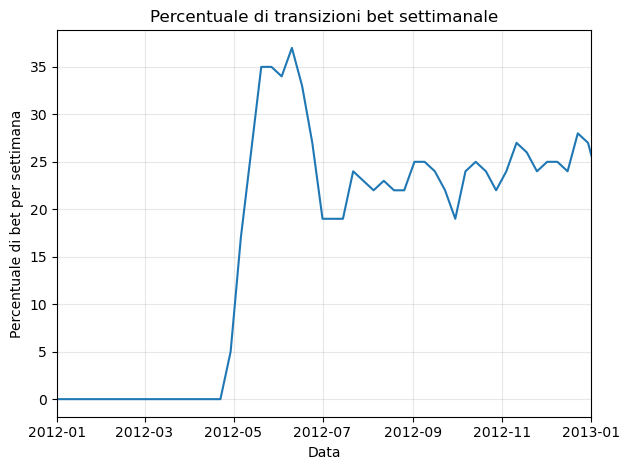

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


    
sns.lineplot(
    data= percentuali_bet ,
    x="datetime_utc",
    y="percentuale_bet",
)
plt.xlim(
    pd.Timestamp("2012-01-01", tz="UTC"),
    pd.Timestamp("2013-01-01", tz="UTC")
)
plt.xlabel("Data")
plt.ylabel("Percentuale di bet per settimana")
plt.title("Percentuale di transizioni bet settimanale")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Valutare la popolarità di ogni indirizzo di betting, calcolata considerando,
rispettivamente, il numero di bet per ogni indirizzo con prefisso 1dice contenuto
nel file e l’amount complessivo delle bet per quell’indirizzo. Presentare un grafico che
confronti la popolarità dei vari indirizzi.

In [9]:
sumBetTransactions=betTransactions.groupby(['txId','address']).agg(
    complexiveAmountSatoshi=("amount_satoshi","sum"),
    complexiveAmountBtc=("amount_btc","sum")
)
sumBetTransactions=sumBetTransactions.reset_index('txId')

#display(sumBetTransactions.head(5))
satoshiTransactions=pd.merge(
    sumBetTransactions,
    satoshi_dice,
    left_on="address",
    right_on="Address",
    how="inner")
#display(satoshiTransactions.head(5))

popularity = (
satoshiTransactions.groupby("Name").agg(
        numberOfBets=("txId","nunique"),
        totalAmountSatoshi=("complexiveAmountSatoshi","sum"),
        totalAmountBtc=("complexiveAmountBtc","sum")
    )
)
display(popularity.head(5))


,numberOfBets,totalAmountSatoshi,totalAmountBtc
Name,,,
lessthan 1,60417,57057284641,570.572846
lessthan 1000,72019,1785664070235,17856.640702
lessthan 12000,48532,6751217269093,67512.172691
lessthan 128,15490,181045842063,1810.458421
lessthan 1500,19852,600942077754,6009.420778


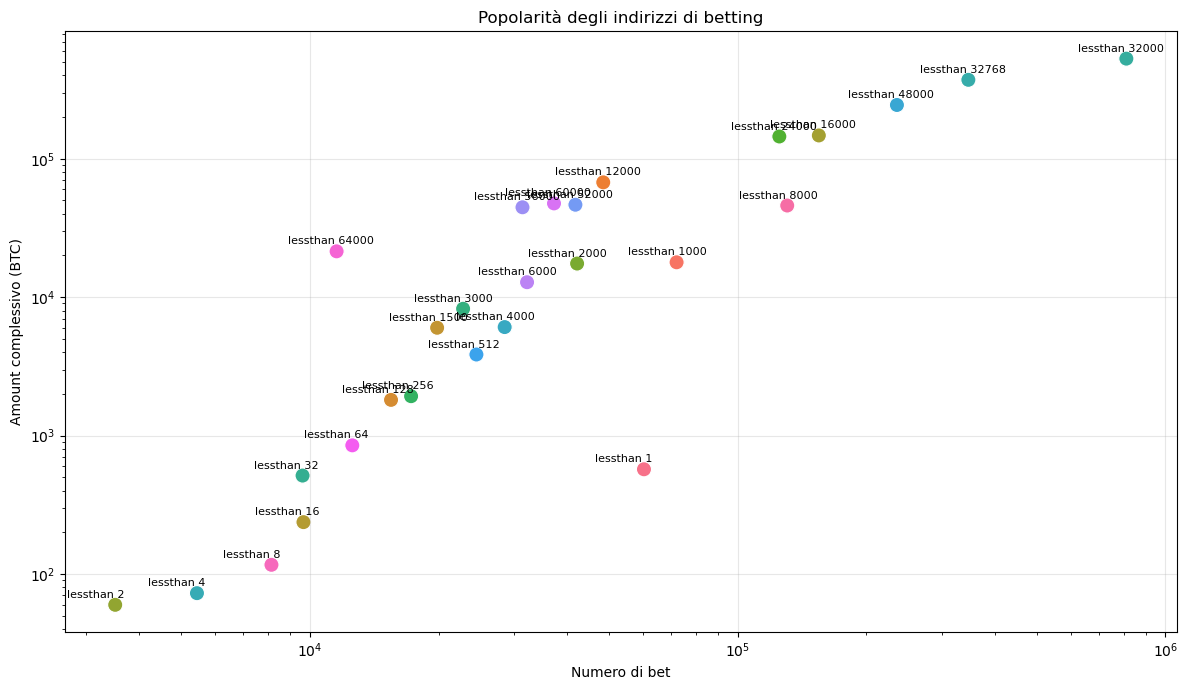

In [10]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=popularity,
    x="numberOfBets",
    y="totalAmountBtc",
    hue="Name",
    s=120,
    legend=False
)

if "Name" in popularity.index.names:
    popularity = popularity.reset_index()
    
for _, row in popularity.iterrows():
    plt.annotate(
        row["Name"],
        (row["numberOfBets"], row["totalAmountBtc"]),
        xytext=(-35, 5),#specifica spostamento testo
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Numero di bet")
plt.ylabel("Amount complessivo (BTC)")
plt.title("Popolarità degli indirizzi di betting")
plt.grid(alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()

Valutare la distanza tra transazioni di bet e corrispondenti transazioni di payout. Una transazione di payout è considerata associata a una transazione di bet se un input della
transazione consuma un UTXO della corrispondente transazione di bet (ovvero un
output non speso della transazione di bet).

In [11]:
# Output delle bet identificati dalla coppia (txId, position).
betUtxos = (
    betTransactions[["txId", "position", "datetime_utc"]]
    .drop_duplicates()
    .rename(columns={"txId": "betTxId", "position": "betPosition", "datetime_utc": "betDate"})
)

# Un payout e' la transazione il cui input spende l'output della bet.
payoutInputs = (
    inputs.loc[inputs["prevTxId"].isin(betUtxos["betTxId"])]
    .rename(columns={"txId": "payoutTxId","prevTxId": "betTxId","prevTxPos": "betPosition"})
)

betPayout = (
    betUtxos.merge(
        payoutInputs,
        on=["betTxId", "betPosition"],
        how="inner"
    )
    [["betTxId", "payoutTxId", "betDate"]]
    .drop_duplicates()
)

# Associamo la data UTC al payout.
transactionDates = transactions[["txId", "datetime_utc"]]

betPayout = betPayout.merge(
    transactionDates.rename(
        columns={"txId": "payoutTxId", "datetime_utc": "payoutDate"}
    ),
    on="payoutTxId",
    how="inner"
)

# La sottrazione tra date UTC restituisce direttamente un Timedelta.
betPayout["distance"] = betPayout["payoutDate"] - betPayout["betDate"]
betPayout["distanceMinutes"] = betPayout["distance"].dt.total_seconds() / 60

invalidPairs = betPayout.loc[betPayout["distance"] < pd.Timedelta(0)]
validPairs = betPayout.loc[betPayout["distance"] >= pd.Timedelta(0)]

print(f"Coppie valide: {len(validPairs):,}")
print(f"Coppie con distanza negativa: {len(invalidPairs):,}")
display(validPairs["distanceMinutes"].describe())
display(validPairs)

Coppie valide: 2,336,744
Coppie con distanza negativa: 13,340


count    2.336744e+06
mean     1.266834e+01
std      2.189601e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.621233e+04
Name: distanceMinutes, dtype: float64

,betTxId,payoutTxId,betDate,payoutDate,distance,distanceMinutes
0,2883791,2883967,2012-04-21 17:02:44+00:00,2012-04-21 17:28:41+00:00,0 days 00:25:57,25.95
1,2883916,2883985,2012-04-21 17:28:41+00:00,2012-04-21 17:28:41+00:00,0 days 00:00:00,0.00
2,2883948,2883990,2012-04-21 17:28:41+00:00,2012-04-21 17:28:41+00:00,0 days 00:00:00,0.00
3,2883966,2883992,2012-04-21 17:28:41+00:00,2012-04-21 17:28:41+00:00,0 days 00:00:00,0.00
4,2883974,2883994,2012-04-21 17:28:41+00:00,2012-04-21 17:28:41+00:00,0 days 00:00:00,0.00
...,...,...,...,...,...,...
2350079,10572820,10572821,2012-12-31 23:52:37+00:00,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.00
2350080,10572820,10572822,2012-12-31 23:52:37+00:00,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.00
2350081,10572820,10572824,2012-12-31 23:52:37+00:00,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.00
2350082,10572820,10572825,2012-12-31 23:52:37+00:00,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.00


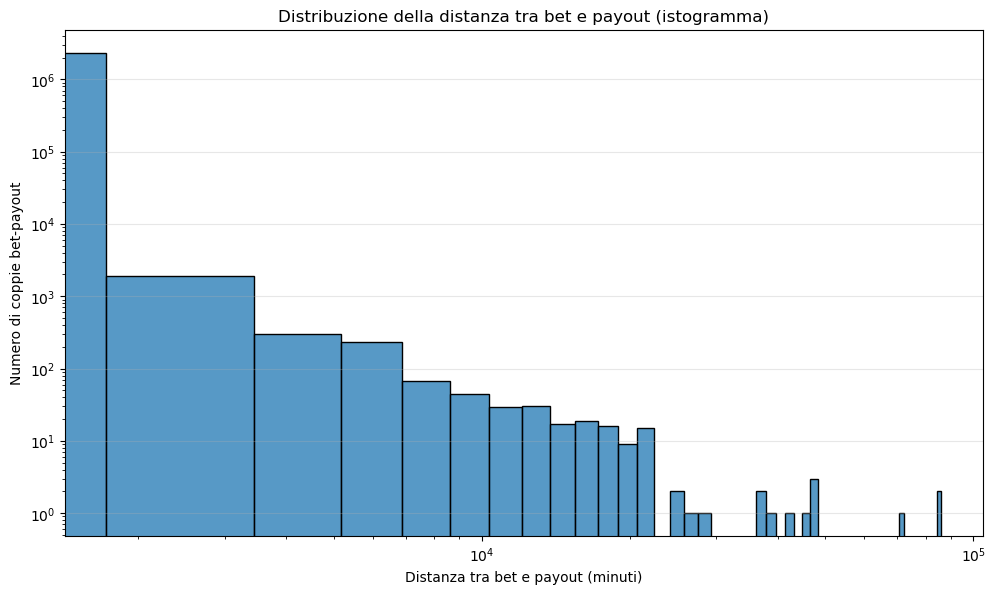

In [48]:
#mostro fino a 99 percentile
validPairsLimit = validPairs[
    "distanceMinutes"
].quantile(0.99)

validPairsLimitPlot = validPairs.loc[
    validPairs["distanceMinutes"] <= validPairsLimit
].copy()


plt.figure(figsize=(10, 6))

sns.histplot(
    data=validPairs,
    x="distanceMinutes",
    bins=50
)

plt.xlabel("Distanza tra bet e payout (minuti)")
plt.ylabel("Numero di coppie bet-payout")
plt.title("Distribuzione della distanza tra bet e payout (istogramma)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.xscale("log")
plt.yscale("log")

plt.show()

,timeIntervals,numberOfBetPayout
0,0,1943283
1,1-5,71776
2,6-30,207700
3,30-60,58268
4,1-5 min,42540
5,5-10 min,6029
6,>10 min,7148


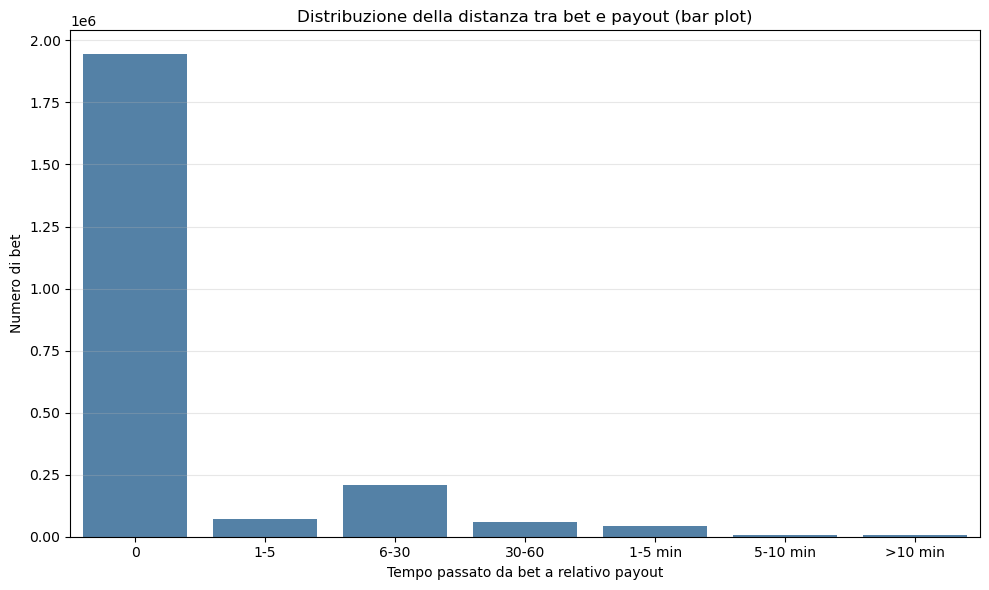

In [37]:
ValidPairsBarPlot = validPairs.copy()
ValidPairsBarPlot["timeIntervals"] = pd.cut(
    ValidPairsBarPlot["distanceMinutes"],
    bins=[-0.001,0,5,30,60,300,600,float("inf")]
    ,
    labels=[
        "0", "1-5", "6-30", "30-60",
        "1-5 min", "5-10 min", ">10 min" 
    ]
)

ValidPairsDistribution = (
    ValidPairsBarPlot
    .groupby("timeIntervals", observed=False)
    .size()
    .rename("numberOfBetPayout")
    .reset_index()
)
display(ValidPairsDistribution)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=ValidPairsDistribution,
    x="timeIntervals",
    y="numberOfBetPayout",
    color="steelblue"
)

plt.xlabel("Tempo passato da bet a relativo payout")
plt.ylabel("Numero di bet")
plt.title("Distribuzione della distanza tra bet e payout (bar plot)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Eseguire le seguenti analisi, separatamente per i 3 indirizzi più popolari
* Distribuzione temporale delle bet: 
 analizzare come le puntate
sono distribuite nel tempo, utilizzando diverse scale temporali (ad esempio:
per ora, per giorno, per settimana).
* Analisi correlazione tra fee e amount della bet Verificare
l’eventuale presenza di una correlazione tra le fee di transazione e l’importo
scommesso
* Intervallo tra bet consecutive: analizzare la distribuzione del
tempo intercorso tra una puntata e la successiva.

In [16]:
addressPopularity = satoshiTransactions.groupby(['Name','Address'])['txId'].nunique()
top_3_names = addressPopularity.sort_values(ascending=False).head(3)

top_3_names_df = (
    top_3_names
    .rename("numberOfBets")
    .reset_index()
    .rename(columns={'Address': 'address'})
)

top_3_names_stats = pd.merge(
    betTransactions,
    top_3_names_df,
    on='address',
    how='inner'
)
timeS_top_3_names_stats = top_3_names_stats.set_index('datetime_utc').sort_index()
display(top_3_names_stats.head())


,timestamp,blockId,txId,isCoinbase,fee,fee_btc,datetime_utc,position,addressId,amount_satoshi,scriptType,amount_btc,address,Name,numberOfBets
0,1335029321,176629,2883983,0,50000,0.0005,2012-04-21 17:28:41+00:00,1,3517367,500000000,2,5.000,1dice9wcMu5hLF4g81u8nioL5mmSHTApw,lessthan 48000,235719
1,1335032189,176632,2884218,0,50000,0.0005,2012-04-21 18:16:29+00:00,0,3517636,2000000,2,0.020,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,lessthan 32768,346206
2,1335033873,176634,2884336,0,500000,0.0050,2012-04-21 18:44:33+00:00,0,3517636,5000000,2,0.050,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,lessthan 32768,346206
3,1335066618,176695,2887087,0,0,0.0000,2012-04-22 03:50:18+00:00,0,3517636,25000000,2,0.250,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,lessthan 32768,346206
4,1335079749,176719,2887926,0,50000,0.0005,2012-04-22 07:29:09+00:00,1,3517636,100000,2,0.001,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,lessthan 32768,346206


analizzare come le puntate sono distribuite nel tempo, utilizzando diverse scale temporali (ad esempio:
per ora, per giorno, per settimana).

In [17]:

top_3_names_stats_hour = (
    timeS_top_3_names_stats
    .groupby("Name")
    .resample('h')["txId"]
    .nunique()
    .rename("numberOfBets")
    .reset_index()
)

top_3_names_stats_day = (
    timeS_top_3_names_stats
    .groupby("Name")
    .resample('D')["txId"]
    .nunique()
    .rename("numberOfBets")
    .reset_index()
)
top_3_names_stats_week = (
    timeS_top_3_names_stats
    .groupby("Name")
    .resample('W')["txId"]
    .nunique()
    .rename("numberOfBets")
    .reset_index()
)
display(top_3_names_stats_day)

,Name,datetime_utc,numberOfBets
0,lessthan 32000,2012-04-22 00:00:00+00:00,2
1,lessthan 32000,2012-04-23 00:00:00+00:00,0
2,lessthan 32000,2012-04-24 00:00:00+00:00,12
3,lessthan 32000,2012-04-25 00:00:00+00:00,191
4,lessthan 32000,2012-04-26 00:00:00+00:00,43
...,...,...,...
759,lessthan 48000,2012-12-27 00:00:00+00:00,1457
760,lessthan 48000,2012-12-28 00:00:00+00:00,1588
761,lessthan 48000,2012-12-29 00:00:00+00:00,1921
762,lessthan 48000,2012-12-30 00:00:00+00:00,1145


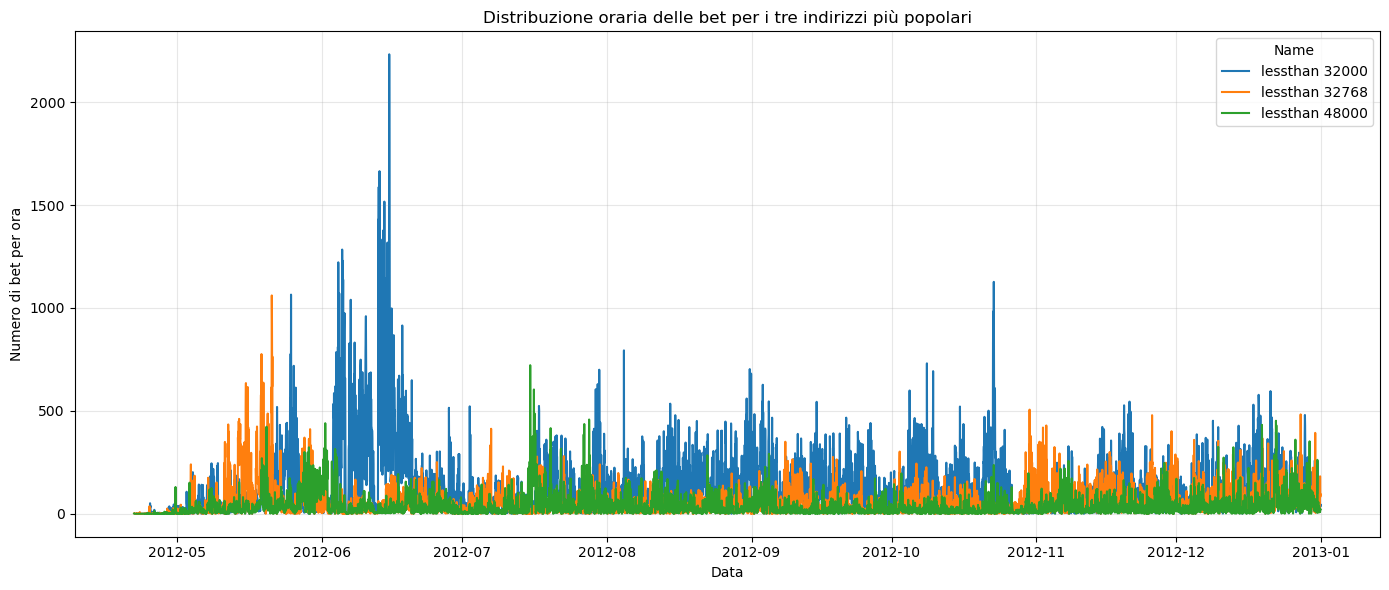

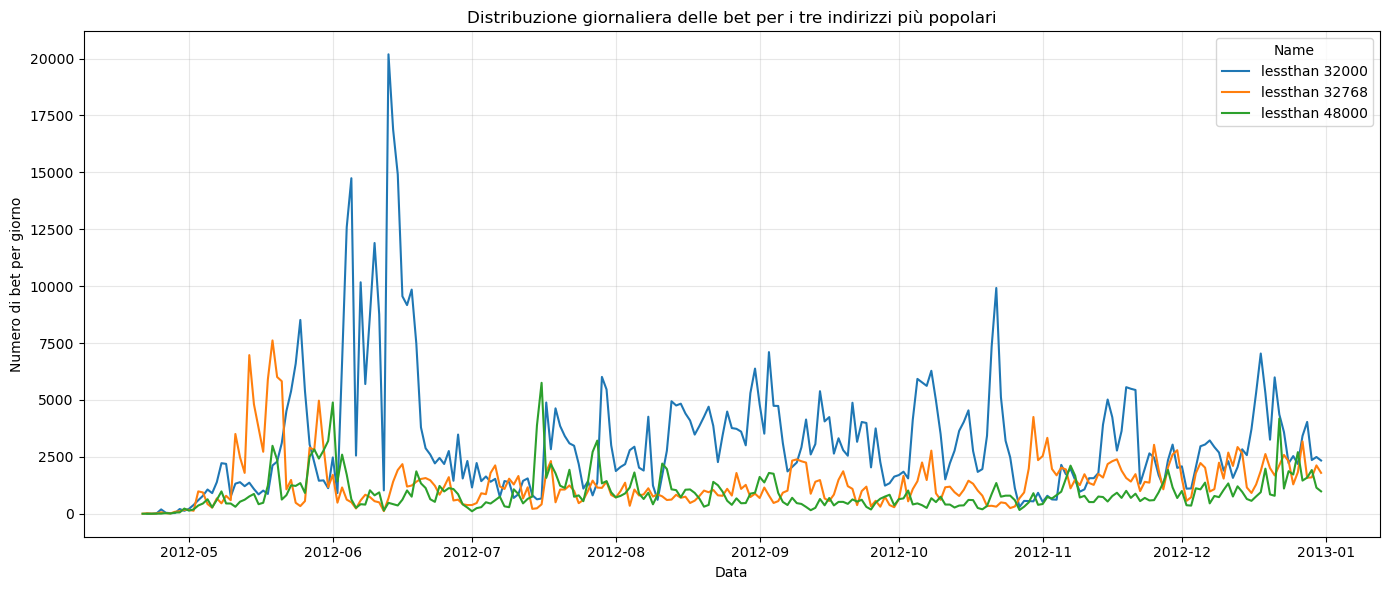

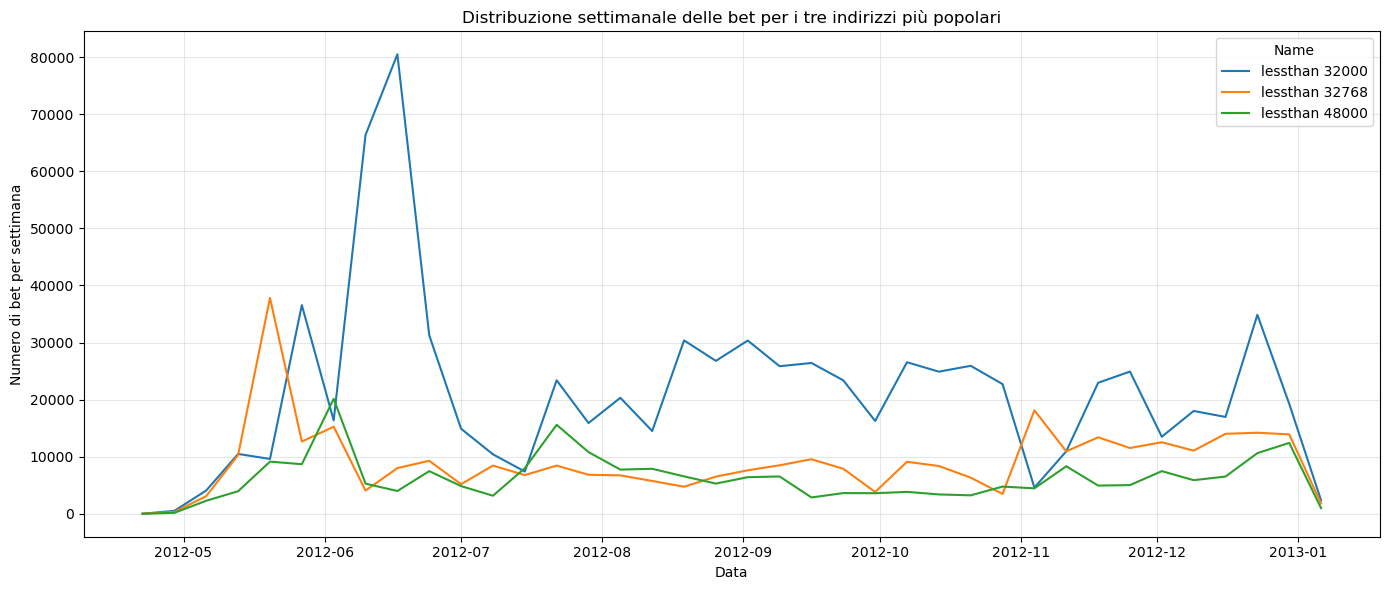

In [18]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=top_3_names_stats_hour,
    x="datetime_utc",
    y="numberOfBets",
    hue="Name"
)

plt.xlabel("Data")
plt.ylabel("Numero di bet per ora")
plt.title("Distribuzione oraria delle bet per i tre indirizzi più popolari")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 6))

sns.lineplot(
    data=top_3_names_stats_day,
    x="datetime_utc",
    y="numberOfBets",
    hue="Name"
)

plt.xlabel("Data")
plt.ylabel("Numero di bet per giorno")
plt.title("Distribuzione giornaliera delle bet per i tre indirizzi più popolari")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=top_3_names_stats_week,
    x="datetime_utc",
    y="numberOfBets",
    hue="Name"
)

plt.xlabel("Data")
plt.ylabel("Numero di bet per settimana")
plt.title("Distribuzione settimanale delle bet per i tre indirizzi più popolari")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Analisi correlazione tra fee e amount della bet. Verificare l’eventuale presenza di una correlazione tra le fee di transazione e l’importo scommesso (scatter plot)

In [19]:
feeImportCorrelation = (
    top_3_names_stats
    .groupby(["Name","txId"], as_index=False)
    .agg(
        betAmountSatoshi=("amount_satoshi", "sum"),
        fee=("fee", "first"),
        betAmountBtc=("amount_btc","sum"),
        fee_btc=("fee_btc", "first")
    )
)
feeImportCorrelation

,Name,txId,betAmountSatoshi,fee,betAmountBtc,fee_btc
0,lessthan 32000,2890967,100000,50000,0.001,0.0005
1,lessthan 32000,2890972,100000,50000,0.001,0.0005
2,lessthan 32000,2903154,100000,50000,0.001,0.0005
3,lessthan 32000,2903347,100000,50000,0.001,0.0005
4,lessthan 32000,2903353,100000,50000,0.001,0.0005
...,...,...,...,...,...,...
1392132,lessthan 48000,10572727,8000000,50000,0.080,0.0005
1392133,lessthan 48000,10572734,8000000,50000,0.080,0.0005
1392134,lessthan 48000,10572744,8000000,100000,0.080,0.0010
1392135,lessthan 48000,10572760,16400000,50000,0.164,0.0005


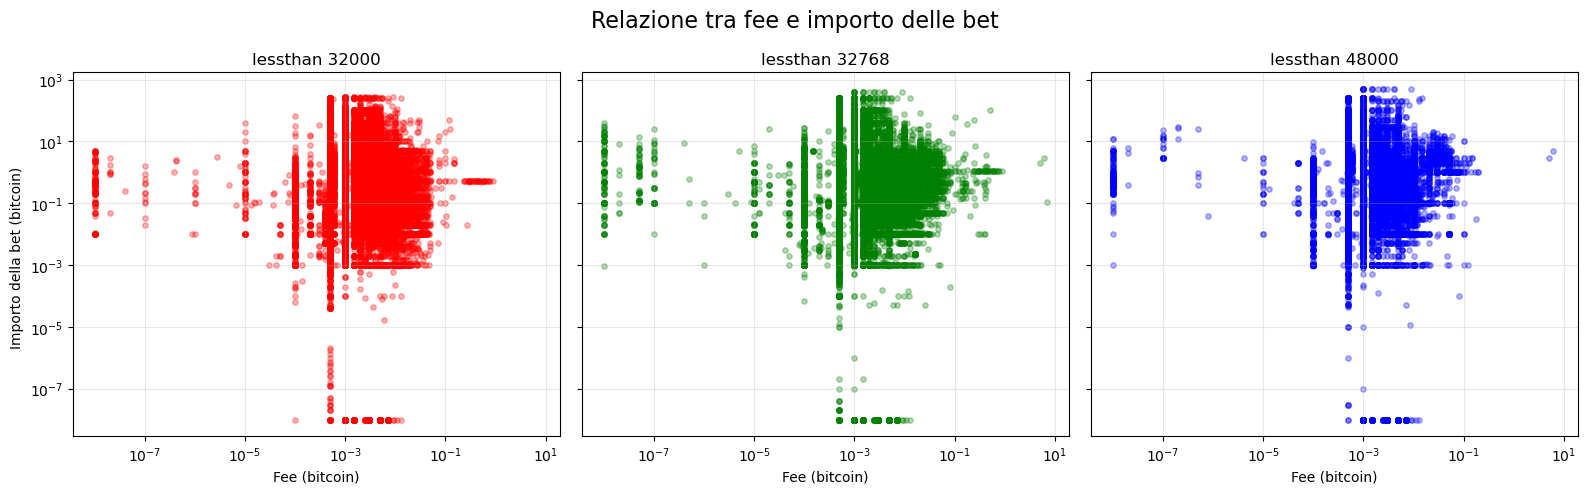

In [20]:
colors = ['red','green','blue']
i = 0
names = feeImportCorrelation["Name"].unique()

fig, axes = plt.subplots( #subplot restituisce coppia (fig,axes) dove fig intera figura, axes singoli grafici
    1,
    len(names),
    figsize=(16, 5),
    sharex=True,
    sharey=True
)

fig.suptitle(
    "Relazione tra fee e importo delle bet",
    fontsize=16
)

for axis, name in zip(axes, names): #zip() abbina gli elementi di due sequenze posizione per posizione
    subset = feeImportCorrelation[
        feeImportCorrelation["Name"] == name
    ]

    axis.scatter(
        subset["fee_btc"],
        subset["betAmountBtc"],
        s=15,
        alpha=0.3,
        color= colors[i],
    )

    axis.set_title(name)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Fee (bitcoin)")
    axis.grid(alpha=0.3)
    i += 1

axes[0].set_ylabel("Importo della bet (bitcoin) ")

plt.tight_layout()
plt.show()

In [21]:
display(
    feeImportCorrelation
    .sort_values(
    by="fee",
    ascending=True
    ).head()
)

,Name,txId,betAmountSatoshi,fee,betAmountBtc,fee_btc
741292,lessthan 32000,9783398,10000000,0,0.10,0.0
770367,lessthan 32000,10088738,112000000,0,1.12,0.0
770366,lessthan 32000,10088737,1000000,0,0.01,0.0
869749,lessthan 32768,3395159,20000000,0,0.20,0.0
376459,lessthan 32000,6011301,50000000,0,0.50,0.0


Intervallo tra bet consecutive: analizzare la distribuzione del tempo intercorso tra una puntata e la successiva

In [22]:
consecutiveBets = (
    top_3_names_stats[["Name","txId","datetime_utc"]]
    .drop_duplicates(subset="txId")
    .sort_values(["Name","datetime_utc"])
)

consecutiveBets["timeFromLastBet"] = (
    consecutiveBets
    .groupby("Name")["datetime_utc"]
    .diff()
)

consecutiveBets["secondsFromLastBet"] = (
    consecutiveBets["timeFromLastBet"]
    .dt.total_seconds()
)
consecutiveBets["minutesFromLastBet"] = (
    consecutiveBets["timeFromLastBet"]
    .dt.total_seconds()/60
)
consecutiveBets["hoursFromLastBet"] = (
    consecutiveBets["timeFromLastBet"]
    .dt.total_seconds()/3600
)
plotData = consecutiveBets.dropna(
    subset=["secondsFromLastBet"]
).copy()

plotData


,Name,txId,datetime_utc,timeFromLastBet,secondsFromLastBet,minutesFromLastBet,hoursFromLastBet
8,lessthan 32000,2890972,2012-04-22 18:22:51+00:00,0 days 00:00:00,0.0,0.000000,0.000000
33,lessthan 32000,2903154,2012-04-24 12:18:11+00:00,1 days 17:55:20,150920.0,2515.333333,41.922222
42,lessthan 32000,2904651,2012-04-24 17:39:49+00:00,0 days 05:21:38,19298.0,321.633333,5.360556
45,lessthan 32000,2904655,2012-04-24 17:39:49+00:00,0 days 00:00:00,0.0,0.000000,0.000000
49,lessthan 32000,2905349,2012-04-24 18:51:29+00:00,0 days 01:11:40,4300.0,71.666667,1.194444
...,...,...,...,...,...,...,...
1394082,lessthan 48000,10572727,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.0,0.000000,0.000000
1394085,lessthan 48000,10572734,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.0,0.000000,0.000000
1394088,lessthan 48000,10572744,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.0,0.000000,0.000000
1394093,lessthan 48000,10572760,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.0,0.000000,0.000000


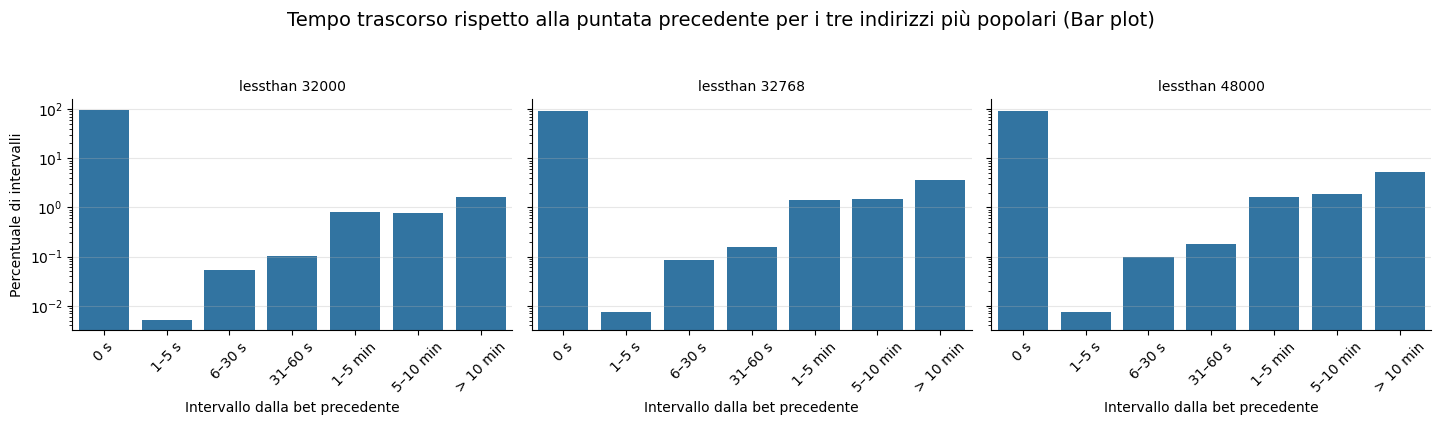

In [23]:
plotData["timeRange"] = pd.cut(
    plotData["secondsFromLastBet"],
    bins=[-0.001,0,5,30,60,300,600,float("inf")],
    labels=["0 s","1–5 s","6–30 s","31–60 s","1–5 min","5–10 min","> 10 min"]
)

timeDistribution = (
    plotData
    .groupby(
        ["Name", "timeRange"],
        observed=True
    )
    .size() 
    .rename("numberOfIntervals")
    .reset_index()
)

timeDistribution["percentage"] = (
    timeDistribution["numberOfIntervals"]
    / timeDistribution.groupby("Name")["numberOfIntervals"].transform("sum")* 100
)

graph = sns.catplot(
    data=timeDistribution,
    x="timeRange",
    y="percentage",
    col="Name",
    kind="bar",
    col_wrap=3,
    height=4,
    aspect=1.2,
    sharey=True
)

graph.set_axis_labels(
    "Intervallo dalla bet precedente",
    "Percentuale di intervalli"
)

graph.set_titles("{col_name}")

for axis in graph.axes.flat:
    axis.tick_params(
        axis="x",
        rotation=45
    )
    axis.grid(
        axis="y",
        alpha=0.3
    )

graph.figure.suptitle(
    "Tempo trascorso rispetto alla puntata precedente per i tre indirizzi più popolari (Bar plot)",
    fontsize=14,
    y=1.05
)

plt.yscale("log")
plt.tight_layout()
plt.show()

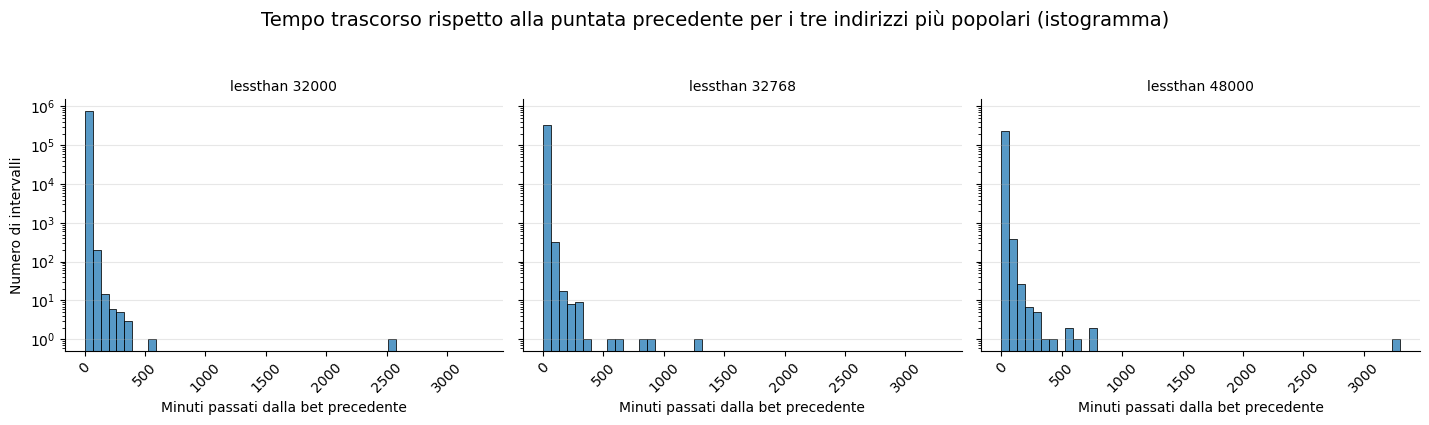

In [24]:
graph = sns.displot(
    data=plotData,
    x="minutesFromLastBet",
    col="Name",
    col_wrap=3,
    kind="hist",
    bins=50,
    height=4,
    aspect=1.2,
    facet_kws={
        "sharex": True,
        "sharey": True
    }
)

graph.set_axis_labels(
    "Minuti passati dalla bet precedente",
    "Numero di intervalli"
)

graph.set_titles("{col_name}")

for axis in graph.axes.flat:
    axis.tick_params(
        axis="x",
        rotation=45
    )
    axis.grid(
        axis="y",
        alpha=0.3
    )
    axis.set_yscale("log")

graph.figure.suptitle(
    "Tempo trascorso rispetto alla puntata precedente per i tre indirizzi più popolari (istogramma)",
    fontsize=14,
    y=1.05
)

plt.yscale("log")
plt.tight_layout()
plt.show()

## Fase 4
Grafo

Catena di bets

si
considerano esclusivamente le “simple bet”, ovvero transazioni caratterizzate da un solo
input e da esattamente due output, di cui uno destinato a un indirizzo 1dice di
SatoshiDice e l’altro identificato come output di resto (change). Due restricted bet
consecutive appartengono alla stessa catena se e solo se l’input della seconda coincide con
l’output di resto della prima e l'altro output è indirizzato a uno degli indirizzi 1dice. In tal
modo, ogni catena rappresenta una sequenza lineare di transazioni in cui il resto di una
puntata viene riutilizzato come input della puntata successiva

L’analisi sarà limitata alle simple bet associate all’indirizzo 1dice caratterizzato dal maggior
numero di transazioni nel dataset

Al fine di individuare tali catene, si richiede di costruire un
grafo diretto 𝐺 = (𝑉, 𝐸), in cui:
* ogni nodo 𝑣 ∈ 𝑉 rappresenta una singola simple bet;
* esiste un arco diretto (𝑣 , 𝑣 ) ∈ 𝐸 se e solo se l’ input della simple bet j corrisponde
all’ output di resto della simple bet 𝑖 ;ù
* a ciascun arco è associata un’etichetta che identifica l’indirizzo responsabile del
collegamento tra le due bet.

In [25]:
inputCounts = (
    inputs.groupby("txId")["txId"]
    .transform("size")
)
singleInputTransactions = inputs.loc[
    inputCounts == 1
].copy()
multipleInputTransactions = inputs.loc[
    inputCounts >= 1
].copy()
display(len(singleInputTransactions))
display(singleInputTransactions)

7257855

,txId,prevTxId,prevTxPos
0,171,9,0
1,183,171,1
2,185,183,1
3,187,185,1
4,192,187,0
...,...,...,...
21378763,10572821,10572820,3
21378764,10572822,10572820,4
21378765,10572823,10572820,7
21378766,10572824,10572820,5


In [26]:
most_popular_address = addressPopularity.sort_values(ascending=False).reset_index().head(1)

mappingTransactionsOutput["isMostPopularAddress"] = (
    mappingTransactionsOutput["address"]
        .isin(most_popular_address["Address"])
)

mappingTransactionsOutput["outputCount"] = (
    mappingTransactionsOutput
    .groupby("txId")["txId"]
    .transform("size")
)

mappingTransactionsOutput["isBetAddress"] = (
    mappingTransactionsOutput["address"]
    .str.startswith("1dice", na=False)
)

mappingTransactionsOutput["hasBetAddress"] = (
    mappingTransactionsOutput
    .groupby("txId")["isBetAddress"]
    .transform("any")
)

mappingTransactionsOutput["hasMostPopularAddress"] = (
    mappingTransactionsOutput
    .groupby("txId")["isMostPopularAddress"]
    .transform("any")
)

mappingTransactionsOutput["hasBothBetAddresses"] = (
    mappingTransactionsOutput
    .groupby("txId")["isBetAddress"]
    .transform("all")
)

twoOutputsBetTransactions = mappingTransactionsOutput.loc[
    (mappingTransactionsOutput["outputCount"] == 2)
    & (mappingTransactionsOutput["hasMostPopularAddress"])
    & ~(mappingTransactionsOutput["hasBothBetAddresses"])
].copy()

print("Numero di righe:", len(twoOutputsBetTransactions))

print(
    "Numero di transazioni:",
    twoOutputsBetTransactions["txId"].nunique()
)

display(twoOutputsBetTransactions.sort_values(
    by=["txId","position"],
    ascending=True
))


Numero di righe: 1470208
Numero di transazioni: 735104


,timestamp,blockId,txId,isCoinbase,fee,fee_btc,datetime_utc,position,addressId,amount_satoshi,scriptType,amount_btc,address,isMostPopularAddress,outputCount,isBetAddress,hasBetAddress,hasMostPopularAddress,hasBothBetAddresses
6734162,1335118971,176781,2890967,0,50000,0.0005,2012-04-22 18:22:51+00:00,0,3524393,2800630,2,0.028006,1A4YPUgekvFBTpGWakSwuQMaxGaPTifDq3,False,2,False,True,True,False
6734163,1335118971,176781,2890967,0,50000,0.0005,2012-04-22 18:22:51+00:00,1,3524394,100000,2,0.001000,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,True,2,True,True,True,False
6734172,1335118971,176781,2890972,0,50000,0.0005,2012-04-22 18:22:51+00:00,0,3524398,2650630,2,0.026506,1AmB2fS5Yd3ghm5gnATNJRi7E7CcxwFyPk,False,2,False,True,True,False
6734173,1335118971,176781,2890972,0,50000,0.0005,2012-04-22 18:22:51+00:00,1,3524394,100000,2,0.001000,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,True,2,True,True,True,False
6769431,1335293489,177055,2905349,0,50000,0.0005,2012-04-24 18:51:29+00:00,0,3524394,400000,2,0.004000,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,True,2,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24570786,1356996072,214558,10571901,0,350000,0.0035,2012-12-31 23:21:12+00:00,1,8707915,1942460,2,0.019425,1DYve98WqJQmx6cDdW2EQFpnqfwptjV4e9,False,2,False,True,True,False
24571818,1356996754,214559,10572338,0,50000,0.0005,2012-12-31 23:32:34+00:00,0,8708602,1167339,2,0.011673,1GfipQ9LadLRpRV1qMqLMJwBfR2m8Xx3p1,False,2,False,True,True,False
24571819,1356996754,214559,10572338,0,50000,0.0005,2012-12-31 23:32:34+00:00,1,3524394,3000000,2,0.030000,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,True,2,True,True,True,False
24572086,1356997591,214561,10572428,0,0,0.0000,2012-12-31 23:46:31+00:00,0,3524394,200000000,2,2.000000,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,True,2,True,True,True,False


In [85]:
simpleBetOutputs = twoOutputsBetTransactions[["txId","position","address","isBetAddress","amount_btc"]]

simpleBets = (
    simpleBetOutputs
    .merge(
        singleInputTransactions,
        on = "txId",
        how = "inner"
    )
)

changeOutputs = (
    simpleBets.loc[
        ~simpleBets["isBetAddress"],
        ["txId", "position", "address" ]
    ]
    .drop_duplicates()
    .rename(columns={
        "txId": "previousBetTxId",
        "position": "previousBetPosition",
        "address": "changeAddress"
    })
)

simpleBetIds = simpleBets["txId"].unique()

simpleBetInputs = (
    singleInputTransactions.loc[
        singleInputTransactions["txId"].isin(simpleBetIds),
        ["txId", "prevTxId", "prevTxPos"]
    ]
    .rename(columns={
        "txId": "currentBetTxId"
    })
)

betLinks = simpleBetInputs.merge(
    changeOutputs,
    left_on=["prevTxId", "prevTxPos"],
    right_on=[
        "previousBetTxId",
        "previousBetPosition"
    ],
    how="inner"
)
display(betLinks)

,currentBetTxId,prevTxId,prevTxPos,previousBetTxId,previousBetPosition,changeAddress
0,2890972,2890967,0,2890967,0,1A4YPUgekvFBTpGWakSwuQMaxGaPTifDq3
1,2908490,2908434,0,2908434,0,18nGa7G7BaG659BXWkzNo1uAdXZDNwpXB1
2,2908500,2908478,0,2908478,0,1JSP9JzRE95dyAZjH7gx8PiMQ5GD9Bzsii
3,2908501,2908479,0,2908479,0,1KV3W3RiHk4sPw3gVVMEXfUWZJiZ9PET2K
4,2908502,2908480,0,2908480,0,18EhHZZjimnmtxpF8MScrRsBX7JSwuEUmg
...,...,...,...,...,...,...
311837,10570747,10570745,1,10570745,1,18b8YqBkD6ENSgz241cfEFh3L5e9eV8vEH
311838,10570795,10570749,1,10570749,1,18b8YqBkD6ENSgz241cfEFh3L5e9eV8vEH
311839,10570883,10570674,1,10570674,1,18b8YqBkD6ENSgz241cfEFh3L5e9eV8vEH
311840,10570885,10570747,1,10570747,1,18b8YqBkD6ENSgz241cfEFh3L5e9eV8vEH


In [28]:
import networkx as nx

g = nx.DiGraph()

for previousBet, currentBet, changeAddress in zip(betLinks["previousBetTxId"], betLinks["currentBetTxId"], betLinks["changeAddress"]):   
    g.add_edge(previousBet, currentBet, label = changeAddress)

print("Numero di nodi:", g.number_of_nodes())
print("Numero di archi:", g.number_of_edges())

Numero di nodi: 395969
Numero di archi: 311842


Una volta costruito il grafo, si richiede di:
1.  identificare le catene di simple bet come cammini nel grafo;
2. calcolare la distribuzione delle lunghezze di tali catene (in termini di numero di nodi o
di archi);
3. rappresentare graficamente tale distribuzione, al fine di analizzare la struttura e la
persistenza delle sequenze di gioco.

In [155]:
components = list(
    nx.weakly_connected_components(g)
)

print("Numero di catene:", len(components))

chainStats = pd.DataFrame([
    {
        "chainId": chainId,
        "numberOfNodes": len(component),
        "numberOfEdges": g.subgraph(component).number_of_edges()
    }
    for chainId, component in enumerate(components,start=1)
])
display(chainStats.sort_values(by="numberOfNodes", ascending=False).head(30))

Numero di catene: 84127


,chainId,numberOfNodes,numberOfEdges
10937,10938,717,716
11804,11805,442,441
10125,10126,352,351
8192,8193,293,292
4533,4534,273,272
12093,12094,246,245
62657,62658,243,242
10358,10359,235,234
8785,8786,233,232
8748,8749,229,228


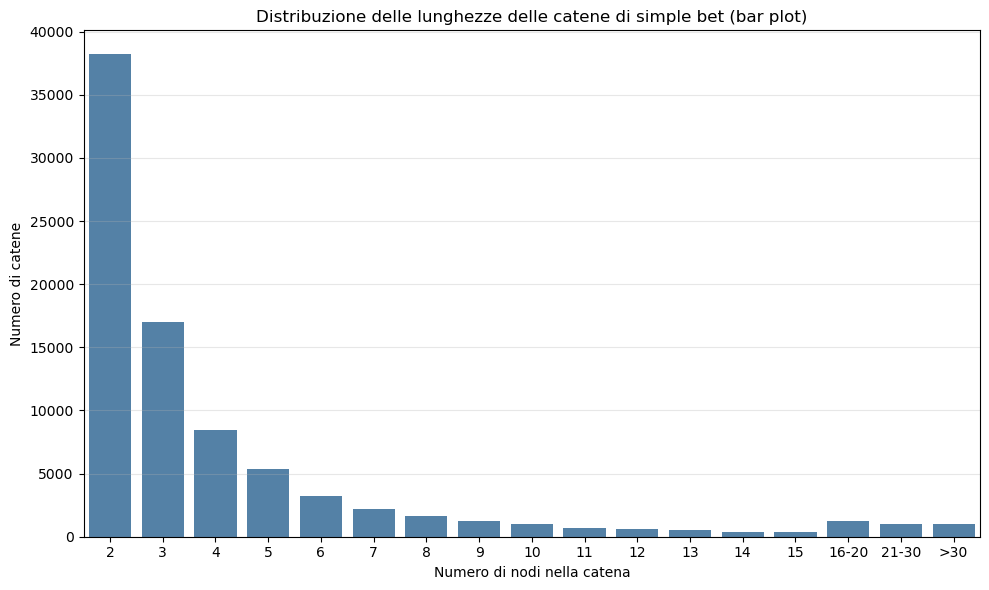

In [96]:
chainStatsPlot = chainStats.copy()
chainStatsPlot["intervals"] = pd.cut(
    chainStatsPlot["numberOfNodes"],
    bins=[
        1.5, 2.5, 3.5, 4.5,
        5.5, 6.5, 7.5, 8.5, 9.5,
        10.5, 11.5, 12.5, 13.5, 14.5,
        15.5, 20.5, 30.5 , float("inf")
    ],
    labels=[
        "2", "3", "4", "5",
        "6", "7", "8", "9", "10",
        "11", "12", "13", "14", "15",
        "16-20", "21-30", ">30" 
    ]
)

chainDistribution = (
    chainStatsPlot
    .groupby("intervals", observed=False)
    .size()
    .rename("numberOfChains")
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=chainDistribution,
    x="intervals",
    y="numberOfChains",
    color="steelblue"
)

plt.xlabel("Numero di nodi nella catena")
plt.ylabel("Numero di catene")
plt.title("Distribuzione delle lunghezze delle catene di simple bet (bar plot)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



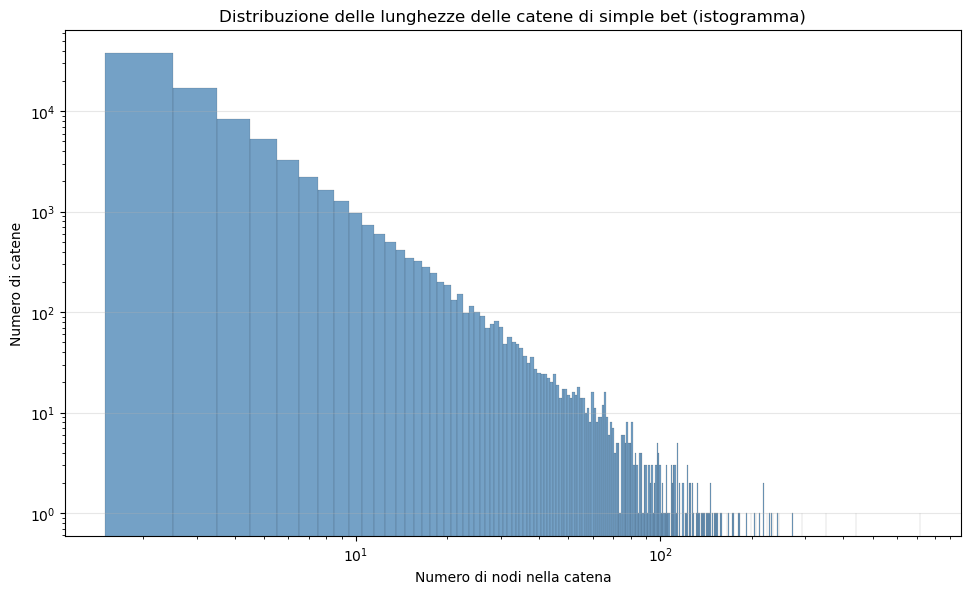

In [97]:
#mostro fino a 99 percentile
nodeLimit = chainStats[
    "numberOfNodes"
].quantile(0.99)

chainStatsPlot = chainStats.loc[
    chainStats["numberOfNodes"] <= nodeLimit
].copy()


plt.figure(figsize=(10, 6))
sns.histplot(
    data=chainStats,
    x="numberOfNodes",
    color="steelblue",
    discrete=True
)

plt.xlabel("Numero di nodi nella catena")
plt.ylabel("Numero di catene")
plt.title("Distribuzione delle lunghezze delle catene di simple bet (istogramma)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.xscale("log")
plt.yscale("log")
plt.show()


## Fase 5

Limitatamente alle ℎ catene di bet di lunghezza massima individuate nella fase precedente, si
richiede di verificare se gli indirizzi associati agli archi di ciascuna catena appartengano a un
medesimo wallet.

In particolare, per ogni catena selezionata, si dovrà considerare l’insieme degli indirizzi che
etichettano gli archi del grafo (ossia gli indirizzi che realizzano il collegamento tra bet
consecutive) e verificarne l’appartenenza a uno stesso wallet.

A tal fine, si richiede di effettuare web scraping sul servizio WalletExplorer, utilizzando
le informazioni disponibili per determinare se tutti gli indirizzi appartengono allo stesso
wallet. Si ricorda che su WalletExplorer, un wallet non è un singolo indirizzo, ma un
cluster di indirizzi Bitcoin che si ritiene appartengano alla stessa entità.
WalletExplorer raggruppa indirizzi la multi-input heuristic che prevede che, se più
indirizzi compaiono come input nella stessa transazione, probabilmente sono controllati dallo
stesso utente. Inoltre, quando possibile, WalletExplorer associa questi wallet a entità
note (come exchange o servizi), effettuando una forma di de-anonimizzazione parziale della
blockchain.

L’analisi richiesta dovrà stabilire se:
- tutti gli indirizzi di una catena sono riconducibili a un unico wallet;
- oppure se la catena coinvolge indirizzi appartenenti a wallet distinti.
  
I risultati dell’analisi dovranno includere, per ciascuna catena individuata, almeno le seguenti
informazioni:
- identificativo univoco della catena;
- lunghezza della catena (espressa in numero di nodi o, alternativamente, di archi);
- numero totale di indirizzi coinvolti;
- numero di wallet distinti identificati;
- percentuale di indirizzi riconducibili al wallet predominante;
- identificativo del wallet principale
Nel caso in cui il wallet principale sia stato deanonimizzato, l’identificativo corrisponderà al
nome del servizio così come riportato su WalletExplorer; in caso contrario, sarà
utilizzato l’identificativo numerico assegnato da WalletExplorer al wallet stesso.

In [127]:
def drawBetChain(
    subgraph,
    title="Catena di simple bet",
    showNodes=True
):

    print("Numero di nodi:", subgraph.number_of_nodes())
    print("Numero di archi:", subgraph.number_of_edges())

    positions = nx.spring_layout(
        subgraph,
        iterations=15,
        seed=1721
    )

    fig, axis = plt.subplots(
        figsize=(14, 7)
    )

    nx.draw(
        subgraph,
        positions,
        ax=axis,
        with_labels=False,
        node_size=20,
        node_color="lightblue",
        arrows=True,
        font_size=8,
        width=0.5
    )

    
    axis.set_title(title)
    axis.axis("off")

    plt.tight_layout()
    plt.show()

def buildLabelsList(
    subgraph
):
    return [
        attributes["label"]
        for _,_,attributes in subgraph.edges(data=True)
    ]

In [158]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import Select
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.keys import Keys
import time

def betChainInfoDf(chainNumber,subgraph, dataframe):
    
    labelsList = buildLabelsList(subgraph)
    numberOfDistinctLabels = len(set(labelsList))
    
    driver=webdriver.Safari()
    print(driver.service.path)
    
    wallets = dict()
    walletsLength = dict()
    
    try:
        driver.get(url)
        #driver.maximize_window()
        wait = WebDriverWait(driver, 10)
        
        for address in labelsList:
            driver.get(
                f"https://www.walletexplorer.com/address/{address}"
            )
            walletName = wait.until(EC.presence_of_element_located((By.CLASS_NAME,"wallet_name"))).text.strip("[]")
    
            wallets.setdefault(walletName, []).append(address)
            
            walletLengths = {walletName:len(addresses) for walletName, addresses in wallets.items()}
        
        mainWallet=max(walletLengths,
            key=walletLengths.get)
        
        perc_indirizzi_mainWallet = (len(wallets[mainWallet])/subgraph.number_of_edges())*100       

        dataframe.loc[len(dataframe)]={
        "id_catena": chainNumber,
        "lunghezza_catena": subgraph.number_of_nodes(),
        "indirizzi_coinvolti": numberOfDistinctLabels,
        "wallet_distinti": len(wallets),
        "perc_indirizzi_mainWallet": perc_indirizzi_mainWallet,
        "id_mainWallet": mainWallet
        }

    finally:
        driver.quit()
    return dataframe

Numero di nodi: 219
Numero di archi: 218


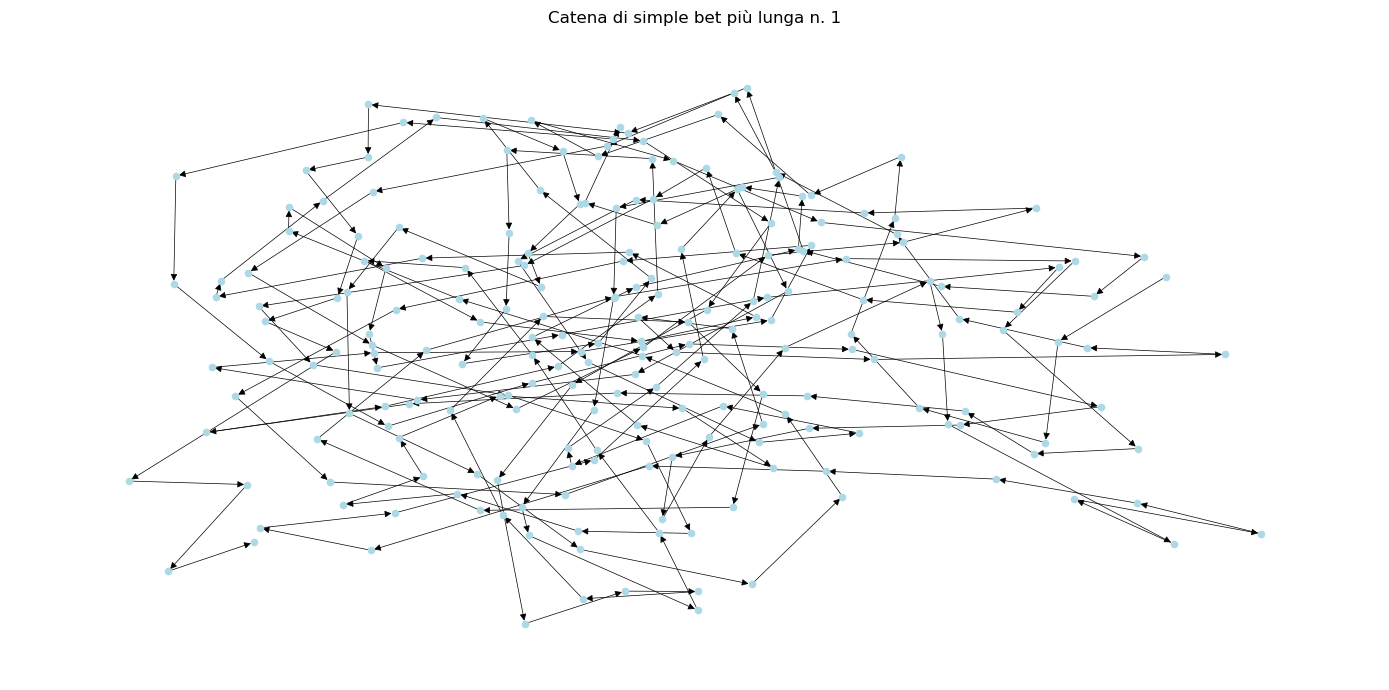

/usr/bin/safaridriver
Numero di nodi: 219
Numero di archi: 218


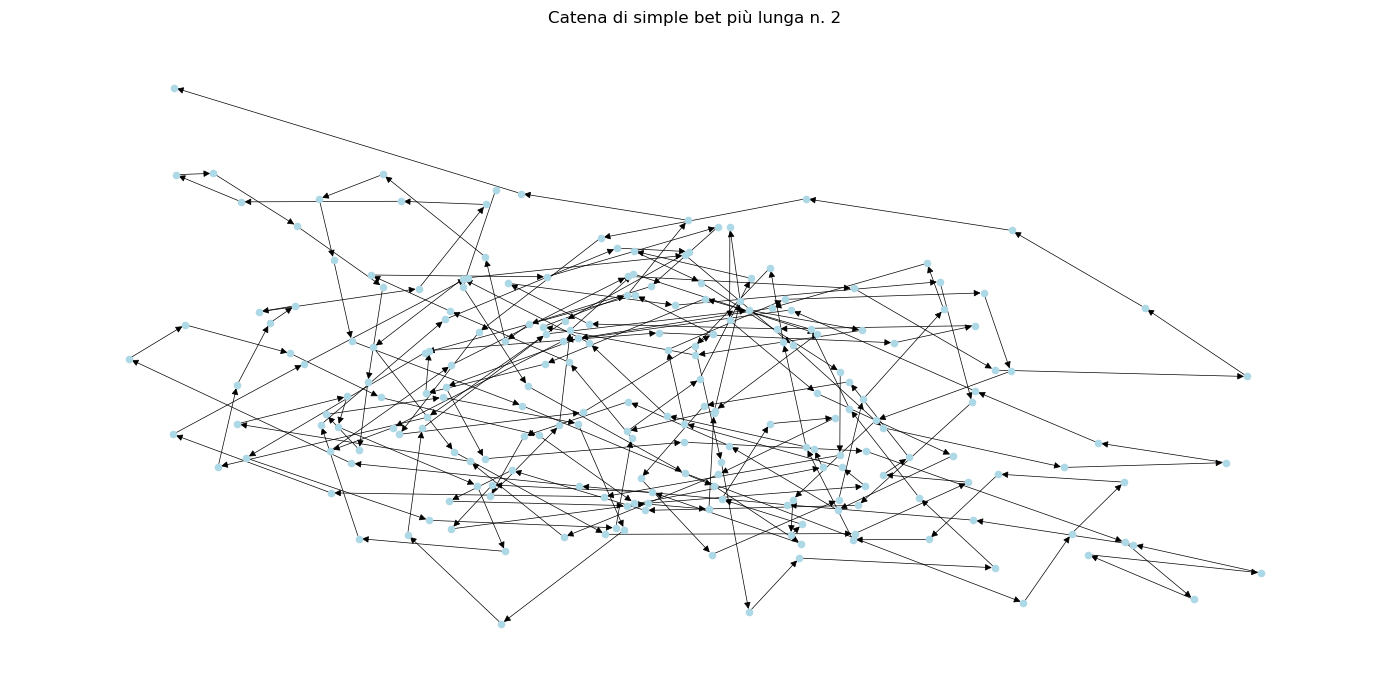

/usr/bin/safaridriver


,id_catena,lunghezza_catena,indirizzi_coinvolti,wallet_distinti,perc_indirizzi_mainWallet,id_mainWallet
0,1,219,218,3,93.577982,00094ec34f
1,2,219,218,1,100.000000,0004509035


In [161]:
dataframe = pd.DataFrame(
    columns=[
        "id_catena",
        "lunghezza_catena",
        "indirizzi_coinvolti",
        "wallet_distinti",
        "perc_indirizzi_mainWallet",
        "id_mainWallet"
    ]
)

maxLength = max(
    len(component)
    for component in components
)

maxLengthComponents = [
    component
    for component in components
    if len(component) == 219#maxLength
]

for chainNumber, component in enumerate(maxLengthComponents,start=1):
    subgraph = g.subgraph(component).copy()
    drawBetChain(subgraph,title=(f"Catena di simple bet più lunga n. {chainNumber}"))
    dataframe = betChainInfoDf(chainNumber, subgraph, dataframe)
display(dataframe)